# Fine-Tuning de um Modelo Transformer para Classificação de Sentimento

## Bibliotecas usadas

In [3]:
!pip install -q numpy==2.0.2
!pip install -q keras
!pip install -q spacy
!pip install -q tensorflow
!pip install -q keras-preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00


In [4]:
# Imports
import math
import nltk
import spacy
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import transformers
from tokenizers import BertWordPieceTokenizer
from tqdm import tqdm
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from keras_preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences
from keras.metrics import Precision, Recall, AUC
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from keras.callbacks import EarlyStopping, LearningRateScheduler, CallbackList, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from keras.saving import register_keras_serializable
from tensorflow.keras.layers import Layer, Dense
from transformers import TFDistilBertModel, DistilBertConfig
from tensorflow.keras.metrics import Precision, Recall, AUC
import warnings
warnings.filterwarnings('ignore')

## Dados

Dados extraidos da platoforma hugging face

https://huggingface.co/datasets/carblacac/twitter-sentiment-analysis

In [ ]:
dados_treino = pd.read_csv('dados_treino_p2.txt', header= None, delimiter=';')
dados_treino.head()

In [6]:
dados_teste = pd.read_csv('dados_teste_p2.txt', header= None, delimiter=';')
dados_teste.head()

,0,1
0,i feel like my only role now would be to tear ...,sadness
1,i feel just bcoz a fight we get mad to each ot...,anger
2,i feel like reds and purples are just so rich ...,joy
3,im not sure the feeling of loss will ever go a...,sadness
4,i feel like ive gotten to know many of you thr...,joy


In [7]:
dados_treino = dados_treino.rename(columns={0: 'texto', 1: 'sentimento'})
dados_teste = dados_teste.rename(columns={0: 'texto', 1: 'sentimento'})

In [8]:
print(dados_treino.shape)
print(dados_teste.shape)

(16000, 2)
(2000, 2)


In [9]:
print(dados_treino['sentimento'].value_counts())

sentimento
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [10]:
dados_teste['sentimento'].value_counts()

,count
sentimento,
joy,695
sadness,581
anger,275
fear,224
love,159
surprise,66


obs: importante que a saída dos dados de treino e teste sejam a mesma.

## Pré-processamento de dados de texto com spacy

In [11]:
#Restart kernel
#import IPython
#IPython.Application.instance().kernel.do_shutdown(True)


In [12]:
#!python -m pip install spacy -q
#!python -m spacy download en_core_web_md
#%pip install -U spacy
%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 34.8 MB/s eta 0:00:00


In [13]:
nlp = spacy.load('en_core_web_md')

In [14]:
text = "Machine learning is the ability of a machine to improve its performance on a specific task"
doc = nlp(text)
type(doc)

spacy.tokens.doc.Doc

In [15]:
for token in doc:
    print(token.text, "-",token.pos_,"-" ,token.lemma_, "-", token.is_stop)


Machine - NOUN - machine - False
learning - NOUN - learning - False
is - AUX - be - True
the - DET - the - True
ability - NOUN - ability - False
of - ADP - of - True
a - DET - a - True
machine - NOUN - machine - False
to - PART - to - True
improve - VERB - improve - False
its - PRON - its - True
performance - NOUN - performance - False
on - ADP - on - True
a - DET - a - True
specific - ADJ - specific - False
task - NOUN - task - False


In [16]:
## Função para pré-processamento de texto
def pre_process(text):
    doc = nlp(text)
    tokens = [token.lemma_.lower().strip() for token in doc if not token.is_stop]
    return ' '.join(tokens)

In [17]:
pre_process(text)

'machine learning ability machine improve performance specific task'

In [18]:
dados_treino['texto_processado'] = dados_treino['texto'].apply(pre_process)

In [19]:
dados_teste['texto_processado'] = dados_teste['texto'].apply(pre_process)

In [20]:
dados_treino.head(1)

,texto,sentimento,texto_processado
0,i am feeling completely overwhelmed i have two...,fear,feel completely overwhelmed strategy help feel...


In [21]:
dados_treino.shape

(16000, 3)

A função `pre_process` recebeu um texto bruto e realizou um pré-processamento clássico de NLP usando o spaCy, transformando o texto em uma versão padronizada e mais adequada para análises posteriores. Primeiro, o texto é processado pelo pipeline nlp, que tokeniza e analisa linguisticamente o conteúdo. Em seguida, a função percorre cada token, remove palavras irrelevantes (stopwords), converte cada termo para sua forma base (lematização), padroniza para letras minúsculas e elimina espaços extras. Por fim, os tokens processados são reunidos novamente em uma única string, separada por espaços, resultando em um texto limpo, normalizado e menos ruidoso, apropriado para tarefas como vetorização, classificação ou análise exploratória de textos.

## Modelo 1 - Arquitetura Fully Connect Neural Network

## 1. Vetorização com TF-IDF

In [22]:
tf_idf = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')

Esta linha acima cria uma instância do `TfidfVectorizer` da biblioteca scikit-learn, que é uma ferramenta utilizada para converter uma coleção de documentos brutos em uma matriz de recursos TF-IDF (Term Frequency-Inverse Document Frequency). O TF-IDF é uma técnica estatística usada para quantificar a importância de uma palavra em um conjunto de documentos, comumente utilizada em tarefas de processamento de linguagem natural e recuperação de informações.

**Parâmetro max_df=0.95**: Este parâmetro define o limite máximo de frequência de documento para os termos que serão considerados. Aqui, está definido como 0.95, o que significa que palavras que aparecem em mais de 95% dos documentos serão ignoradas. Isso ajuda a eliminar palavras comuns que não contribuem muito para o significado do texto.

**Parâmetro min_df=2**: Este parâmetro estabelece a frequência mínima de documento para os termos. Neste caso, termos que aparecem em menos de 2 documentos serão ignorados. Isso ajuda a filtrar termos raros que podem ocorrer apenas em poucas amostras e, portanto, são menos relevantes para a análise geral.

**Parâmetro stop_words='english'**: Este parâmetro instrui o vetorizador a remover todas as palavras de parada em inglês da análise. Palavras de parada são palavras comuns (como "e", "o", "em") que geralmente são filtradas em processamento de linguagem natural porque são muito frequentes e não carregam informações significativas para a análise de texto.

In [23]:
#Aplica a vetorização
dados_treino_tfidf = tf_idf.fit_transform(dados_treino['texto_processado'])
dados_treino_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 112822 stored elements and shape (16000, 5593)>

o objeto tf_idf aprende o vocabulário a partir dos textos de treino. Ele identifica todas as palavras que aparecem, calcula com que frequência cada palavra ocorre em cada documento (TF) e o quão rara ou comum ela é no conjunto inteiro (IDF). Ao mesmo tempo, ele já transforma cada texto em um vetor numérico, onde cada posição representa uma palavra do vocabulário e o valor indica sua importância naquele texto. Esse aprendizado só é feito nos dados de treino para evitar vazamento de informação.

In [24]:
dados_teste_tfidf = tf_idf.transform(dados_teste['texto_processado'])
dados_teste_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13651 stored elements and shape (2000, 5593)>

o modelo não aprende nada novo. Ele apenas usa o vocabulário e os pesos aprendidos no treino para transformar os textos de teste em vetores numéricos compatíveis. Palavras que não existiam no treino são ignoradas, garantindo que os dados de treino e teste fiquem no mesmo espaço vetorial.

In [25]:
dados_treino_tfidf.shape

(16000, 5593)

In [26]:
dados_teste_tfidf.shape

(2000, 5593)

In [27]:
# Visualizando as features criadas pela vetorização TF-IDF
feature_names = tf_idf.get_feature_names_out()

df_tfidf = pd.DataFrame(
    dados_treino_tfidf[:5].toarray(),  # só os 5 primeiros textos
    columns=feature_names
)

print(df_tfidf.columns)


Index(['aa', 'abandon', 'abandonment', 'abc', 'abdomen', 'abide', 'ability',
       'abit', 'able', 'abroad',
       ...
       'yuuki', 'zach', 'zealand', 'zen', 'zero', 'zest', 'zombie', 'zone',
       'zoom', 'zumba'],
      dtype='object', length=5593)


In [28]:
df_tfidf

,aa,abandon,abandonment,abc,abdomen,abide,ability,abit,able,abroad,...,yuuki,zach,zealand,zen,zero,zest,zombie,zone,zoom,zumba
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.490603,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Trasformar os dados de entrada (texto) para array:

In [29]:
X_treino_array = dados_treino_tfidf.toarray()
X_teste_array = dados_teste_tfidf.toarray()

In [30]:
print(X_treino_array)
X_teste_array.shape

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


(2000, 5593)

Os dados foram vetorizados

### 2. Preparação dos dados

Converter a variavel alvo para representação numérica.

In [31]:
encoder = LabelEncoder()

In [32]:
# Faz o fit e transform na variável alvo em treino
y_treino_le = encoder.fit_transform(dados_treino['sentimento'])
print(np.unique(y_treino_le))

[0 1 2 3 4 5]


In [33]:
y_teste_le = encoder.transform(dados_teste['sentimento'])
print(np.unique(y_teste_le))

[0 1 2 3 4 5]


Tratar o desbalanceamento de classes dando pesos menores para classes com menos dados.

In [34]:
# Peso das classes
pesos_classes = compute_class_weight('balanced', classes = np.unique(y_treino_le), y = y_treino_le)

**compute_class_weight**: Esta é uma função do scikit-learn que calcula os pesos para as classes. Esses pesos podem ser usados em modelos de classificação para dar mais importância a classes que são sub-representadas no conjunto de dados.

**'balanced'**: Este parâmetro indica que os pesos das classes devem ser calculados de forma que equilibrem o conjunto de dados. Isso é feito inversamente proporcional à frequência das classes no conjunto de dados. Classes mais frequentes recebem um peso menor, enquanto classes menos frequentes recebem um peso maior.

**classes = np.unique(y_treino_le)**: Aqui, np.unique(y_treino_le) encontra todas as classes únicas no conjunto de dados de treinamento. O parâmetro classes informa à função compute_class_weight quais são essas classes únicas.

**y = y_treino_le**: Este é o vetor de rótulos do conjunto de dados de treinamento. A função usará esses rótulos para calcular a frequência de cada classe.

O resultado, armazenado em pesos_classes, é um array onde cada classe tem um peso associado. Esses pesos podem ser usados em modelos de classificação (como uma árvore de decisão, um modelo de regressão logística, SVM, etc.) para compensar o desequilíbrio entre as classes.

In [35]:
# Divisão em Dados de Treino e Teste (validação)
X_treino, X_val, y_treino, y_val = train_test_split(X_treino_array,
                                                    y_treino_le,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y_treino_le)

In [36]:
# Ajusta a variável alvo como tipo categórico
y_treino_encoded = to_categorical(y_treino)
y_teste_encoded = to_categorical(y_teste_le)
y_val_encoded = to_categorical(y_val)

### 3. Construção do modelo

In [37]:
# Inicializa um modelo sequencial. Modelos sequenciais são uma pilha linear de camadas.
modelo1 = Sequential()

# Adiciona a primeira camada densa (fully-connected) ao modelo
modelo1.add(Dense(4096, # número de neurônios na camada

                        # Utiliza a função de ativação SELU (Scaled Exponential Linear Unit)
                        activation = 'selu',

                        # Inicializa os pesos com a distribuição LeCun normal
                        kernel_initializer = 'lecun_normal',

                        # Define o formato da entrada com base no número de features do X_treino
                        input_shape = (X_treino.shape[1],),

                        # Aplica regularização L2 para reduzir o overfitting
                        kernel_regularizer = tf.keras.regularizers.l2(0.01)))

# Adiciona a segunda camada densa
modelo1.add(Dense(2048,
                        activation = 'selu',
                        kernel_initializer = 'lecun_normal',
                        kernel_regularizer = tf.keras.regularizers.l2(0.01)))

# Adiciona a terceira camada densa
modelo1.add(Dense(1024,
                        activation = 'selu',
                        kernel_initializer = 'lecun_normal',
                        kernel_regularizer = tf.keras.regularizers.l2(0.1)))

# Adiciona a quarta camada densa
# Camada com 64 neurônios e ativação SELU
modelo1.add(Dense(64, activation = 'selu',))

# Adiciona a camada de saída
# Camada de saída com 6 neurônios e ativação softmax para classificação multiclasse
modelo1.add(Dense(6, activation = 'softmax'))

### 4 - Compilação e sumário do modelo

In [38]:
# Atribui pesos específicos ao vetor de bias da última camada do modelo
modelo1.layers[-1].bias.assign(pesos_classes)

<tf.Tensor: shape=(6,), dtype=float32, numpy=
array([1.2351397 , 1.3766993 , 0.49732688, 2.0449898 , 0.5715102 ,
       4.6620045 ], dtype=float32)>

In [39]:
# Compila o modelo
modelo1.compile(optimizer = 'Adam',  # Define o otimizador como 'Adam'.
                      loss = tf.losses.categorical_crossentropy,
                      metrics = ['accuracy'])

 **Adam** é um algoritmo de otimização que pode ser usado no lugar do procedimento clássico de descida
do gradiente estocástica para atualizar os pesos da rede iterativamente com base nos dados de treinamento.
Define a função de perda como 'categorical_crossentropy'. É adequada para problemas de classificação
multiclasse, onde os rótulos são fornecidos em um formato one-hot encoded.
Define a métrica de avaliação do modelo como 'accuracy' (acurácia).
A acurácia é uma métrica comum para avaliar o desempenho de modelos de classificação.

In [40]:
modelo1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │    22,913,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,467,846 (127.67 MB)

 Trainable params: 33,467,846 (127.67 MB)

 Non-trainable params: 0 (0.00 B)

### 5: Callbacks e Earlystop

In [41]:
def step_decay(epoch):
    initial_lrate = 0.001
    drop = 0.5
    epochs_drop = 10.0
    lrate = initial_lrate * math.pow(drop,
           math.floor((1+epoch)/epochs_drop))
    return lrate

In [42]:
# Agendador de Taxa de Aprendizado
lr_scheduler = LearningRateScheduler(step_decay)

In [43]:
# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', restore_best_weights = True, patience = 3)

### 6: Treinamento do modelo

In [44]:
num_epochs = 20
tamanho_batch = 256

In [45]:
history = modelo1.fit(X_treino,
                      y_treino_encoded,
                      validation_data = (X_val, y_val_encoded),
                      epochs = num_epochs,
                      batch_size = tamanho_batch,
                      callbacks = [early_stopping, lr_scheduler])

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.5409 - loss: 77.6611 - val_accuracy: 0.7837 - val_loss: 2.2242 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8225 - loss: 1.6291 - val_accuracy: 0.7909 - val_loss: 1.3361 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8494 - loss: 1.1512 - val_accuracy: 0.8094 - val_loss: 1.2168 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8701 - loss: 1.0457 - val_accuracy: 0.8378 - val_loss: 1.1111 - learning_rate: 0.0010
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9016 - loss: 0.9247 - val_accuracy: 0.8294 - val_loss: 1.0954 - learning_rate: 0.0010
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9032 - loss: 0.9011 - val_accuracy: 0.8425 - val_loss: 1.0637 - learning_rate: 0.0010
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9219 - loss: 0.8482 - val_ac

### 7. Avaliação do modelo

In [46]:
loss, val_loss = history.history['loss'], history.history['val_loss']

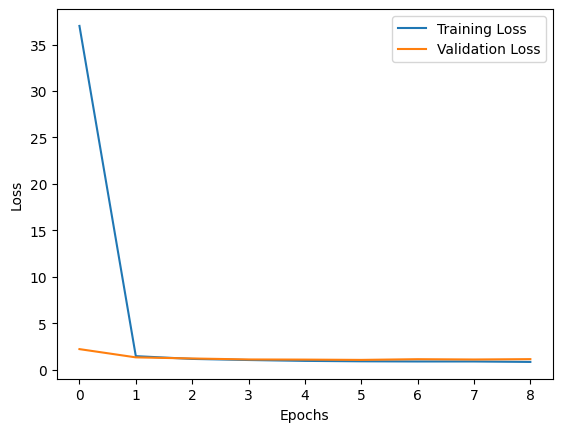

In [47]:
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [48]:
# Extrai previsões do modelo
previsoes1 = modelo1.predict(X_teste_array)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [49]:
previsoes1_labels = previsoes1.argmax(axis = 1)

In [50]:
print("Acurácia:", accuracy_score(y_teste_le, previsoes1_labels))

Acurácia: 0.8345


In [51]:
print(classification_report(y_teste_le, previsoes1_labels))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       275
           1       0.72      0.83      0.78       224
           2       0.89      0.86      0.87       695
           3       0.73      0.57      0.64       159
           4       0.86      0.88      0.87       581
           5       0.65      0.64      0.64        66

    accuracy                           0.83      2000
   macro avg       0.78      0.77      0.78      2000
weighted avg       0.83      0.83      0.83      2000



In [52]:
print("Matriz de confusão:")
print(confusion_matrix(y_teste_le, previsoes1_labels))

Matriz de confusão:
[[235  14   5   2  19   0]
 [ 12 187   2   0  14   9]
 [  9  17 601  29  28  11]
 [  2   2  41  91  20   3]
 [ 17  23  26   2 513   0]
 [  3  15   4   0   2  42]]


A diagonal representa os acertos do modelo, o restante representa os erros.

In [53]:
# Salva o modelo
modelo1.save('modelo_v1.keras')

### 8. Deploy do modelo

In [54]:
modelo_v1 = load_model('modelo_v1.keras')

In [55]:
nova_frase = "it's a new life and i'm feeling good"

In [56]:
# Cria um dataframe com a frase
df_novo = pd.DataFrame({'Frase': [nova_frase]})
# Aplica a função de processamento
df_novo['Frase_Processada'] = df_novo['Frase'].apply(pre_process)
df_novo

,Frase,Frase_Processada
0,it's a new life and i'm feeling good,new life feel good


In [57]:
# Aplica a vetorização
df_novo_tfidf = tf_idf.transform(df_novo['Frase_Processada'])

# Transforma em array
df_novo_array = df_novo_tfidf.toarray()

In [58]:
previsoes_prob = modelo_v1.predict(df_novo_array)
previsoes_prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step


array([[0.01871127, 0.09393536, 0.47723877, 0.08877184, 0.26773056,
        0.05361219]], dtype=float32)

In [59]:
maior_prob_class = np.argmax(previsoes_prob, axis=1)
maior_prob_class


array([2])

In [60]:
nome_classe = encoder.inverse_transform(maior_prob_class)
nome_classe

array(['joy'], dtype=object)

## Modelo 2 - LSTM (Long Short-Term Memory)


In [61]:
dados_treino.head()

,texto,sentimento,texto_processado
0,i am feeling completely overwhelmed i have two...,fear,feel completely overwhelmed strategy help feel...
1,i have the feeling she was amused and delighted,joy,feeling amuse delight
2,i was able to help chai lifeline with your sup...,joy,able help chai lifeline support encouragement ...
3,i already feel like i fucked up though because...,anger,feel like fuck not usually eat morning
4,i still love my so and wish the best for him i...,sadness,love wish good long tolerate effect bm life fa...


**Tokenizador:** Divide os dados de texto em porções menores.

In [62]:
tokenizador = Tokenizer()

In [63]:
tokenizador.fit_on_texts(dados_treino['texto_processado'])

In [64]:
word_index = tokenizador.word_index

In [65]:
for i, (chave, valor) in enumerate(word_index.items()):
  print(chave, valor)
  if i == 9:
    break

feel 1
like 2
m 3
not 4
feeling 5
know 6
time 7
t 8
want 9
think 10


In [66]:
seq_treino = tokenizador.texts_to_sequences(dados_treino['texto_processado'])

In [67]:
max_length = 100 #Comprimeto Máximo das sequências

In [68]:
# Padding das sequências de texto, preenche as posições vazias
seq_treino_padded = tf.keras.preprocessing.sequence.pad_sequences(seq_treino, maxlen = max_length, truncating = 'post')

O "_padding_" é uma técnica comumente usada no processamento de sequências de dados,
especialmente em tarefas de processamento de linguagem natural (PLN).
O padding é usado para padronizar o comprimento das sequências.
Isso é feito adicionando um valor especial (geralmente 0) no início ou no final das sequências para aumentá-las até um comprimento máximo definido. Isso permite que o modelo processe lotes de sequências simultaneamente, o que é essencial para a eficiência do treinamento.

Na linha acima:

**maxlen = max_length**: Este argumento define o comprimento máximo das sequências após o padding. Se uma sequência for mais curta que max_length, ela será estendida com zeros até alcançar esse comprimento. Se for mais longa, será truncada.

**truncating = 'post'**: Este argumento especifica como as sequências devem ser truncadas para o comprimento máximo, caso sejam mais longas que max_length. O valor 'post' indica que o truncamento deve ocorrer no final da sequência. Alternativamente, 'pre' truncaria no início.

O resultado, `seq_treino_padded`, será uma matriz onde cada sequência tem exatamente max_length elementos, com padding de zeros adicionado conforme necessário. Isso torna as sequências compatíveis com muitos modelos de aprendizado de máquina, especialmente aqueles usados em PLN.

In [69]:
seq_teste = tokenizador.texts_to_sequences(dados_teste['texto_processado'])
seq_teste_padded = tf.keras.preprocessing.sequence.pad_sequences(seq_teste, maxlen = max_length, truncating = 'post')

**Label Encoder**

In [70]:
encoder_v2 = LabelEncoder()

In [71]:
y_treino_le = encoder_v2.fit_transform(dados_treino['sentimento'])
print(np.unique(y_treino_le))

[0 1 2 3 4 5]


In [72]:
y_teste_le = encoder_v2.transform(dados_teste['sentimento'])
print(np.unique(y_teste_le))

[0 1 2 3 4 5]


In [73]:
# COnverte os rótulos em variáveis categóricas

y_teste_encoded = to_categorical(y_teste_le)
y_treino_encoded = to_categorical(y_treino_le)

In [74]:
vocab_size = len(tokenizador.word_index) + 1
print(vocab_size)

11836


In [75]:
embedding_dim = max_length

In [115]:
modelo2 = tf.keras.Sequential([Embedding(vocab_size, embedding_dim, input_length = max_length),
                                     Bidirectional(LSTM(64)),
                                     Dropout(0.4),
                                     Dense(32, activation = 'leaky_relu', kernel_regularizer = l1_l2(l1 = 0.01,
                                                                                                     l2 = 0.01)),
                                     Dropout(0.4),
                                     Dense(6, activation = 'softmax')])

In [120]:
# Compilação do modelo
modelo2.compile(loss = 'categorical_crossentropy',
                optimizer = 'adam',
                metrics = ['accuracy', Precision(), Recall(), AUC()])

In [122]:
print(modelo2.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [123]:
dados_entrada = np.array(seq_treino_padded)
dados_saida = np.array(y_treino_encoded)

In [124]:
# Definindo hiperparâmetros
num_epochs = 35
validation_split_value = 0.2
paciencia = 5

# COnfiguração do early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=paciencia, restore_best_weights=True)

Treinamento do Modelo:


In [125]:
%%time
history = modelo2.fit(dados_entrada,
                      dados_saida,
                       epochs = num_epochs,
                       verbose = 1,
                       validation_split = validation_split_value,
                       callbacks = [early_stopping])

Epoch 1/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.3164 - auc: 0.6910 - loss: 3.5533 - precision: 0.4578 - recall: 6.0104e-04 - val_accuracy: 0.3262 - val_auc: 0.7271 - val_loss: 1.6222 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.3438 - auc: 0.7588 - loss: 1.5442 - precision: 0.3618 - recall: 0.0278 - val_accuracy: 0.4206 - val_auc: 0.8450 - val_loss: 1.3024 - val_precision: 0.4873 - val_recall: 0.1975
Epoch 3/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4348 - auc: 0.8572 - loss: 1.2597 - precision: 0.5108 - recall: 0.1694 - val_accuracy: 0.4256 - val_auc: 0.8590 - val_loss: 1.2425 - val_precision: 0.5173 - val_recall: 0.2241
Epoch 4/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4539 - auc: 0.8745 - loss: 1.1536 - precision: 0.5371 - recall: 0.2264 - val_accuracy: 0.4572 - val_auc: 0.8601 - val_loss: 1.2129 - val_precision: 0.4918 - val_recall: 0.3003
Epoch 5/35
400

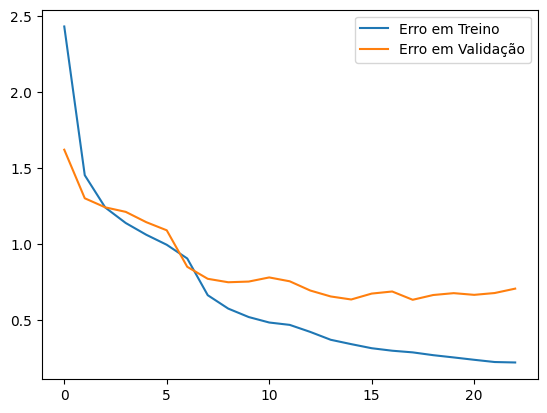

In [126]:
# Plot das curvas de erro
loss, val_loss = history.history['loss'], history.history['val_loss']
plt.plot(loss, label = 'Erro em Treino')
plt.plot(val_loss, label = 'Erro em Validação')
plt.legend()
plt.show()

Previsões do Modelo:

In [132]:
previsoes = modelo2.predict(seq_teste_padded)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [128]:
labels_previstos = previsoes.argmax(axis = 1)

In [129]:
print(classification_report(y_teste_le, labels_previstos))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       275
           1       0.82      0.88      0.85       224
           2       0.91      0.89      0.90       695
           3       0.68      0.72      0.70       159
           4       0.93      0.93      0.93       581
           5       0.76      0.64      0.69        66

    accuracy                           0.88      2000
   macro avg       0.83      0.82      0.83      2000
weighted avg       0.88      0.88      0.88      2000



In [130]:
# Exibição da matriz de confusão
print(confusion_matrix(y_teste_le, labels_previstos))

[[244   8   0   3  20   0]
 [ 10 198   3   0   5   8]
 [  3   5 620  45  17   5]
 [  3   4  37 114   1   0]
 [ 12   8  17   3 541   0]
 [  0  18   4   2   0  42]]


In [131]:
# Exibição da precisão do modelo
print(accuracy_score(y_teste_le, labels_previstos))

0.8795


In [133]:
# Salva o modelo
modelo2.save('modelo_v2.keras')

Deploy do modelo

In [134]:
modelo2 = load_model('modelo_v2.keras')

In [141]:
frase = "I am feeling tired"

In [142]:
df_novo = pd.DataFrame({'Frase': [frase]})

df_novo['Frase_processada'] = df_novo['Frase'].apply(pre_process)


In [143]:
seq_novo = tokenizador.texts_to_sequences(df_novo['Frase_processada'])
seq_novo_padded = tf.keras.preprocessing.sequence.pad_sequences(seq_novo, maxlen = max_length)

In [144]:
previsoes = modelo2.predict(seq_novo_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [145]:
classe_maior_prob = modelo2.predict(seq_novo_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [146]:
classe_maior_prob = previsoes.argmax(axis=1)

print(classe_maior_prob)

[4]


In [147]:
nome_classe = encoder_v2.inverse_transform(classe_maior_prob)

In [148]:
print("A frase:", frase, "foi classificada como:", nome_classe)

A frase: I am feeling tired foi classificada como: ['sadness']


## Modelo 3 - Fine Tunnind de Modelo Transformer pré-treinado

Criar tokenizador personalizado

In [191]:
def encode(texts, tokenizador, chunk_size = 256, maxlen = 512):

  # Ativar trucamento no tokenizador
  tokenizador.enable_truncation(max_length = maxlen)

  # Ativa padding no tokenizador para comprimento específico
  tokenizador.enable_padding(length = maxlen)

  # Inicia uma lista para armazenar os IDs codificados
  input_ids = []
  attention_masks = []

  # Itera sobre os textos em pedaços de temanho chunk_size
  for i in tqdm(range(0, len(texts), chunk_size)):

      # Processa um pedaço do texto
      text_chunk = texts[i:i+chunk_size].tolist()

      # Codifica o pedaço de texto em lotes usando o tokenizador
      encs = tokenizador.encode_batch(texts[i:i+chunk_size].tolist())

      # Adiciona os IDs de entrada codificados à lista input_ids
      input_ids.extend([enc.ids for enc in encs])

      # Adiciona as máscaras de atenção geradas à lista attention_masks
      attention_masks.extend([enc.attention_mask for enc in encs])

  # Retorna os IDs de entrada e as máscaras de atenção como arrays numpy
  return np.array(input_ids), np.array(attention_masks)

https://huggingface.co/distilbert/distilbert-base-multilingual-cased

In [192]:
# Carrega o tokenizador do modelo pré-treinado
tokenizador_bert = transformers.DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')

In [193]:
# Salva o tokenizador e o vocabulário localmente
tokenizador_bert.save_pretrained('.')

('./tokenizer_config.json',
 './special_tokens_map.json',
 './vocab.txt',
 './added_tokens.json')

In [201]:
# Carrega um tokenizador mais veloz usando o vocabulário do tokenizador principal
# from tokenizers import BertWordPieceTokenizer
fast_tokenizer = BertWordPieceTokenizer('vocab.txt', lowercase = False)

In [202]:
print(fast_tokenizer)

Tokenizer(vocabulary_size=119547, model=BertWordPiece, unk_token=[UNK], sep_token=[SEP], cls_token=[CLS], pad_token=[PAD], mask_token=[MASK], clean_text=True, handle_chinese_chars=True, strip_accents=None, lowercase=False, wordpieces_prefix=##)


In [203]:
# Divide os dados em treino e validação com amostragem estratificada
X_treino, X_valid, Y_treino, Y_valid = train_test_split(dados_treino['texto_processado'].values,
                                                        dados_treino['sentimento'].values,
                                                        test_size = 0.2,
                                                        random_state = 42,
                                                        stratify = dados_treino['sentimento'])

In [204]:
# Comprimento máximo usado no texto
max_length = 100

In [198]:
# Aplica a codificação (tokenização) em nossos dados
X_treino_final, mask_treino = encode(X_treino, fast_tokenizer, maxlen=max_length)
X_valid_final, mask_valid = encode(X_valid, fast_tokenizer, maxlen=max_length)
X_teste_final, mask_teste = encode(dados_teste['texto_processado'].to_numpy(), fast_tokenizer, maxlen=max_length)

100%|██████████| 8/8 [00:00<00:00, 100.67it/s]


In [199]:
encoder_v3 = LabelEncoder()

In [200]:
# Aplica o codificador (fit_transform somente nos dados de treino)
y_treino_le = encoder_v3.fit_transform(Y_treino)
y_valid_le = encoder_v3.transform(Y_valid)
y_teste_le = encoder_v3.transform(dados_teste['sentimento'])

In [183]:
# Converte a variável de saída em categórica
y_treino_encoded = to_categorical(y_treino_le)
y_valid_encoded = to_categorical(y_valid_le)
y_teste_encoded = to_categorical(y_teste_le)

In [184]:
# Tamanho do batch
BATCH_SIZE = 16

In [185]:
# Prepara o dataset de treino no formato esperado pelo TensorFlow
dataset_treino = (
    tf.data.Dataset
    .from_tensor_slices(((X_treino_final, mask_treino), y_treino_encoded))
    .repeat()
    .shuffle(2048)
    .batch(BATCH_SIZE)
)

In [186]:
# Prepara o dataset de validação no formato esperado pelo TensorFlow
dataset_valid = (
    tf.data.Dataset
    .from_tensor_slices(((X_valid_final, mask_valid), y_valid_encoded))
    .batch(BATCH_SIZE)
    .cache()
)

In [ ]:
# Prepara o dataset de teste no formato esperado pelo TensorFlow
dataset_teste = (
    tf.data.Dataset
    .from_tensor_slices(((X_teste_final, mask_teste), y_teste_encoded))
    .batch(BATCH_SIZE)
)

O objetivo aqui é o _Transfer Learning_ (Aprendizado por Transferência): usa modelo que já "sabe" língua portuguesa ou inglesa e o adapta para uma tarefa específica de classificação (neste caso, com 6 categorias).


1. Entradas do Modelo (Input):
O modelo não recebe texto puro, mas sim números. Por isso, ele define duas entradas:

`input_word_ids`: São os IDs numéricos de cada palavra (tokens) após o processo de tokenização.

`attention_mask`: Uma máscara binária (0 e 1) que diz ao modelo quais tokens são palavras reais e quais são apenas preenchimento (padding) para completar o tamanho fixo de 512.

2. A Camada Transformer

`TransformerLayer(transformer)`: Aqui, os dados de entrada passam pelo modelo pré-treinado.

`sequence_output`: O resultado dessa camada é uma matriz gigante que contém a representação vetorial de cada palavra na frase, levando em conta o contexto ao redor delas.

In [188]:
# Função para o ajuste fino e treino do modelo usando um transformador
# transformer é o modelo pré treinado
def cria_modelo(transformer, max_len = 512):

    ############ Ajuste Fino ########################################

    # Camada de entrada para IDs das palavras
    input_word_ids = tf.keras.layers.Input(
        shape = (max_len,), dtype = tf.int32, name = "input_word_ids"
    )

    # Camada de entrada para a máscara de atenção
    attention_mask = tf.keras.layers.Input(
        shape = (max_len,), dtype = tf.int32, name = "attention_mask"
    )

    # Camada personalizada para o Transformer
    sequence_output = TransformerLayer(transformer)(
        [input_word_ids, attention_mask]
    )

    # Selecionando o token CLS (primeiro token)
    cls_token = sequence_output[:, 0, :]

    # Camada densa com softmax para classificação
    out = Dense(6, activation = "softmax")(cls_token)

    # Modelo Keras
    modelo = tf.keras.Model(
        inputs = [input_word_ids, attention_mask], outputs=out
    )

    #################################################################

    # Compilando o modelo
    modelo.compile(
        optimizer = Adam(learning_rate = 1e-5),
        loss = "categorical_crossentropy",
        metrics = ["accuracy", Precision(), Recall(), AUC()],
    )

    return modelo

Carrega modelo pré-treinado:
https://huggingface.co/distilbert-base-multilingual-cased

In [189]:
# Registra a classe TransformerLayer como serializável no Keras
@register_keras_serializable(package = "Custom", name = "TransformerLayer")
class TransformerLayer(Layer):

    # Inicializa a classe TransformerLayer com o modelo Transformer e outras configurações
    def __init__(self, transformer, **kwargs):

        # Inicializa a classe base Layer
        super().__init__(**kwargs)

        # Armazena o modelo Transformer na classe
        self.transformer = transformer

    # Define a operação de chamada da camada, executada no momento do treinamento ou inferência
    def call(self, inputs):

        # Desempacota as entradas (input_ids e attention_mask)
        input_ids, attention_mask = inputs

        # Executa o modelo Transformer
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)

        # Retorna a última saída oculta do modelo Transformer
        return outputs.last_hidden_state

    # Define como a camada será serializada
    def get_config(self):

        # Obtém a configuração da classe base
        config = super().get_config()

        # Adiciona a configuração completa do modelo Transformer
        config.update({
            "transformer_config": self.transformer.config.to_dict()  # Salva a configuração do Transformer
        })
        return config  # Retorna a configuração completa da camada

    # Método para recriar a camada a partir de uma configuração salva
    @classmethod
    def from_config(cls, config):

        # Reconstrói a configuração do modelo Transformer a partir do dicionário salvo
        transformer_config = DistilBertConfig.from_dict(config["transformer_config"])

        # Carrega o modelo Transformer pré-treinado com a configuração reconstruída
        transformer = TFDistilBertModel.from_pretrained(
            "distilbert-base-multilingual-cased",
            config=transformer_config
        )

        # Retorna uma nova instância da camada TransformerLayer
        return cls(transformer=transformer)

In [ ]:
# Carregando o modelo pré-treinado
transformer_layer = TFDistilBertModel.from_pretrained(
    "distilbert-base-multilingual-cased"
)

**TFDistilBertModel**: É uma classe dentro da biblioteca transformers. Ela representa o modelo DistilBERT adaptado para TensorFlow. O DistilBERT é uma versão simplificada do BERT que oferece um bom balanço entre desempenho e eficiência. Ele foi treinado para destilar o conhecimento do BERT mantendo a maior parte de sua eficácia, mas com uma arquitetura mais leve e mais rápida para treinamento e inferência.

**from_pretrained**: Este é um método da classe TFDistilBertModel que permite carregar um modelo pré-treinado. Utilizar um modelo pré-treinado permite aproveitar um modelo que já foi treinado em um grande conjunto de dados e aprendeu um bom entendimento da linguagem. Isso é especialmente útil para tarefas de PLN, onde treinar um modelo do zero requer grandes quantidades de dados e poder computacional.

**'distilbert-base-multilingual-cased'**: Este é o identificador do modelo pré-treinado específico que está sendo carregado. Neste caso, é o distilbert-base-multilingual-cased, que é uma versão do DistilBERT que suporta múltiplos idiomas (multilingual) e distingue entre letras maiúsculas e minúsculas (cased). Este modelo foi treinado com textos em vários idiomas, tornando-o útil para aplicações que precisam entender e processar texto em múltiplas línguas.